# Bank Earnings-Call NLP Pipeline: Extract Signals


Apply methods such as topic identification, financial sentiment analysis, keyword / metric extraction, summarisation.




# Setup

In [1]:
import sys
import os
import pathlib
import pandas as pd
import re

# Visual libraries
import matplotlib.pyplot as plt
import seaborn as sns



/Users/johnonyx/projects/boe-financial-analysis/.venv/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.stats import gaussian_kde


In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
#-----------------------------------------------------------------------------------
# Properly add the project root to the path so python can find 'src'
#-----------------------------------------------------------------------------------


def find_project_root(marker: str = "src") -> pathlib.Path:
    path = pathlib.Path.cwd()
    for parent in [path, *path.parents]:
        if (parent / marker).is_dir():
            return parent
    raise RuntimeError(f"Could not find project root (looking for '{marker}') above {path}")


project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [4]:
from src import utils

## Load csv files



In [5]:
df_structured_sentence = pd.read_csv("../../data/output/structured_sentences.csv")
df_structured_utterances = pd.read_csv("../../data/output/structured_utterances.csv")
df_qa_exchanges = pd.read_csv("../../data/output/qa_exchanges_utterance_level.csv")
df_exchange_texts = pd.read_csv("../../data/output/exchange_texts.csv")



In [6]:
CALL_KEY = ["bank", "quarter", "call_type", "call_date"]

In [7]:
df_structured_sentence.describe()

,position_in_call,sentence_id,sentence_number,utterance_id
count,19092.000000,19092.000000,19092.000000,19092.000000
mean,31.166562,33658.500000,18.607008,30.166562
std,31.153569,5511.530005,28.852766,31.153569
min,1.000000,24113.000000,1.000000,0.000000
25%,3.000000,28885.750000,3.000000,2.000000
50%,22.000000,33658.500000,6.000000,21.000000
75%,49.000000,38431.250000,17.000000,48.000000
max,163.000000,43204.000000,180.000000,162.000000


In [8]:
df_structured_utterances.describe()

,position_in_call,text_length,utterance_id
count,2570.000000,2570.000000,2570.000000
mean,46.308949,747.892607,45.308949
std,32.515689,2033.851918,32.515689
min,1.000000,3.000000,0.000000
25%,20.000000,38.250000,19.000000
50%,40.000000,286.000000,39.000000
75%,68.000000,800.500000,67.000000
max,163.000000,30076.000000,162.000000


In [9]:
df_qa_exchanges.describe()


,position_in_call,text_length,utterance_id,qa_exchange_id
count,2473.000000,2473.000000,2473.000000,2473.000000
mean,48.042863,491.655075,47.042863,19.044076
std,31.922194,596.674273,31.922194,12.249037
min,3.000000,3.000000,2.000000,1.000000
25%,22.000000,36.000000,21.000000,9.000000
50%,42.000000,262.000000,41.000000,18.000000
75%,69.000000,768.000000,68.000000,28.000000
max,163.000000,4404.000000,162.000000,57.000000


In [10]:
df_exchange_texts.head(5)

,bank,quarter,call_type,call_date,qa_exchange_id,question_text
0,JPM,2022-Q1,earnings,2022-04-13,1,"Thank you. Morning, Jeremy. Was wondering about the net interest income outlook, I know it sounds like we'll get more at Investor Day, but it's very similar to what you gave in mid-February and obviously rate expectations have advanced since then. Could you give us a little bit of color and what kind of assumptions are underlying the net interest income ex Markets outlook?"
1,JPM,2022-Q1,earnings,2022-04-13,2,"Okay. And as my follow up, could you give us some thoughts about the markets related NII? What things should we think about there, whether it's seasonality or how it's affected by rising rates?"
2,JPM,2022-Q1,earnings,2022-04-13,4,"Hi. Thanks. Good morning. Jeremy, just wanted to follow up on your comments about capital and being able to provide room for organic growth. With 5.2% SLR, 11.9% CET1 versus your longer-term targets, can you talk about what that means in terms of the buyback potential from here? And do any of the RWA inflation items come back off that you just saw in the first quarter? Thanks."
3,JPM,2022-Q1,earnings,2022-04-13,5,"And just a follow up there too, is there anything you need to consider structurally in terms of like adding preferreds to help bridge the gap or is it just going to be enough to organically build back with possibly just utilizing less buybacks to allow things to just grow back?"
4,JPM,2022-Q1,earnings,2022-04-13,8,"I had a question for Jamie. In your annual letter, you mentioned how you expect to achieve double-digit market share over time in payments. And what I wanted to understand is if you could unpack that a little bit because when I look at payments, you've got a lot of different sleeves. For example, in consumer credit card, you're at 20%, 25%. In treasury, I think you're at 7%. So could you give us a sense as to where you think you are in this total payments category you're talking about, what you're expecting in terms of drivers to get to double-digit and what kind of timeframe you're thinking about there? Thanks."


## Topic modelling on analyst questions (utterance-level)

Design choice: the brief asks specifically "what topics do ANALYSTS raise", so the model is trained on the analyst's own words only, not the full
exchange. Folding in management's (much longer) answers would let themodel latch onto whatever vocabulary management uses to respond, rather
than what the analyst actually asked about — the topic label would end updescribing the answer, not the question.


### Implement TF-IDF + NMF 

Design Choice: TF-IDF is chosen over BERTopic because it is well suited for a supervisory use case due to its transparent method: every yopic is an inspectable, weighted list of words unlike BERTopic which is a black box embedding cluster.

**Why TF-IDF + NMF and not BERTopic or LDA?**

I chose NMF over LDA because NMF is deterministic and produces much more coherent, distinct topics on shorter, structured text segments like Q&A responses. Compared to deep learning models like BERTopic, TF-IDF combined with NMF provides total mathematical explainability. For a regulatory institution like the Bank of England, transparency is critical. NMF allowed us to clearly map exactly which terms drove a specific topic cluster without dealing with the 'black box' nature or massive computational overhead of transformer embeddings.


In [11]:
FINANCE_CALL_STOPWORDS = [
    "just", "kind", "guess", "maybe", "morning", "thanks", "thank", "hi",
    "hey", "good", "okay", "ok", "yeah", "yes", "sure", "great", "obviously",
    "actually", "really", "going", "think", "know", "like", "say", "said",
    "question", "questions", "ask", "asked", "asking", "quarter", "quarters",
    # conversational politeness, not subject matter ("appreciate the color", "super helpful").
     "appreciate", "color", "helpful", "super", "insights", "wanted",
    "sounds", "looking", "forward", "taking", "understand", "mean", "case",
    "stay", "right", "longer", "fair", "given", "terms", "sort", "wondering",
    "curious", "follow", "little", "bit", "lot", "got", "gain",

    # Contraction-splitting artefacts: sklearn's tokenizer splits "we've" ->
    # "we"+"ve" and "don't" -> "don"+"t" (the lone "t" is dropped for being
    # a single character, but the 2+ character stems above survive and
    # pollute the vocabulary as meaningless fragments).
    "ve", "ll", "re", "don", "doesn", "isn", "aren", "wasn", "weren",
    "couldn", "wouldn", "shouldn", "hadn", "hasn", "haven", "won", "didn",

]

### Speaker name stopwords

## Build Topic model

In [12]:
#--------------------------------------------------
# Import relevant libraries
#--------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from src import utils

In [13]:
def fit_topic_model(exchange_texts: pd.DataFrame, structured_utterances: pd.DataFrame,
                     n_topics: int = 8, n_top_words: int = 12):
    """
    Input:  exchange_texts (from build_exchange_texts), structured_utterances
            (used only to derive the speaker-name stopword list, not joined
            or merged in no new rows come from it).
    Output: (exchange_texts_with_topic, topic_summary) — both NEW DataFrames.
 
    ngram_range=(1,2) lets bigrams like "credit risk" or "net interest income"
    survive as single features rather than being lost to unigram splitting.
    min_df=3 drops idiosyncratic one-off phrasing; max_df=0.5 drops words so
    common across exchanges they carry no distinguishing signal.
    """
   
    stopwords = (list(TfidfVectorizer(stop_words="english").get_stop_words())
                 + FINANCE_CALL_STOPWORDS
                 + utils._speaker_name_stopwords(structured_utterances))
 
    vectorizer = TfidfVectorizer(
        stop_words=stopwords, ngram_range=(1, 2), min_df=3, max_df=0.5,
    )
    tfidf = vectorizer.fit_transform(exchange_texts["question_text"])
 
    nmf = NMF(n_components=n_topics, random_state=42, max_iter=500)
    doc_topic = nmf.fit_transform(tfidf)  # shape: (n_exchanges, n_topics)
 
    feature_names = vectorizer.get_feature_names_out()
    topic_rows = []
    for topic_id, topic_weights in enumerate(nmf.components_):
        top_idx = topic_weights.argsort()[::-1][:n_top_words]
        topic_rows.append({
            "topic_id": topic_id,
            "top_words": ", ".join(feature_names[i] for i in top_idx),
        })
    topic_summary = pd.DataFrame(topic_rows)
 
    out = exchange_texts.copy()
    out["topic_id"] = doc_topic.argmax(axis=1)
    out["topic_confidence"] = doc_topic.max(axis=1) / (doc_topic.sum(axis=1) + 1e-9)
 
    return out, topic_summary

In [14]:
exchange_topics, topic_summary = fit_topic_model(df_exchange_texts, df_structured_utterances, n_topics=8)

In [15]:
exchange_topics.head(5)

,bank,quarter,call_type,call_date,qa_exchange_id,question_text,topic_id,topic_confidence
0,JPM,2022-Q1,earnings,2022-04-13,1,"Thank you. Morning, Jeremy. Was wondering about the net interest income outlook, I know it sounds like we'll get more at Investor Day, but it's very similar to what you gave in mid-February and obviously rate expectations have advanced since then. Could you give us a little bit of color and what kind of assumptions are underlying the net interest income ex Markets outlook?",6,0.442105
1,JPM,2022-Q1,earnings,2022-04-13,2,"Okay. And as my follow up, could you give us some thoughts about the markets related NII? What things should we think about there, whether it's seasonality or how it's affected by rising rates?",2,0.552009
2,JPM,2022-Q1,earnings,2022-04-13,4,"Hi. Thanks. Good morning. Jeremy, just wanted to follow up on your comments about capital and being able to provide room for organic growth. With 5.2% SLR, 11.9% CET1 versus your longer-term targets, can you talk about what that means in terms of the buyback potential from here? And do any of the RWA inflation items come back off that you just saw in the first quarter? Thanks.",0,0.490117
3,JPM,2022-Q1,earnings,2022-04-13,5,"And just a follow up there too, is there anything you need to consider structurally in terms of like adding preferreds to help bridge the gap or is it just going to be enough to organically build back with possibly just utilizing less buybacks to allow things to just grow back?",0,0.624490
4,JPM,2022-Q1,earnings,2022-04-13,8,"I had a question for Jamie. In your annual letter, you mentioned how you expect to achieve double-digit market share over time in payments. And what I wanted to understand is if you could unpack that a little bit because when I look at payments, you've got a lot of different sleeves. For example, in consumer credit card, you're at 20%, 25%. In treasury, I think you're at 7%. So could you give us a sense as to where you think you are in this total payments category you're talking about, what you're expecting in terms of drivers to get to double-digit and what kind of timeframe you're thinking about there? Thanks.",1,0.784113


In [16]:
display(topic_summary)

,topic_id,top_words
0,0,"capital, cet1, buybacks, thinking, basel, risk, rotce, regulatory, time, years, excess, ratio"
1,1,"credit, private, private credit, card, lending, market, banks, consumer, commercial, credit card, risk, seeing"
2,2,"deposit, nii, deposits, betas, deposit betas, deposit growth, seen, higher, rates, migration, seeing, reprice"
3,3,"wealth, management, wealth management, new, net, flows, net new, second, talk, asia, money, new money"
4,4,"year, billion, nii, rate, year year, spend, guidance, expect, cuts, 10, spending, half"
5,5,"growth, loan, loan growth, demand, outlook, reserve, rwa, year, lending, commercial, opportunities, outlook loan"
6,6,"cost, income, cost income, costs, ratio, income ratio, revenue, revenues, net income, guidance, secondly, fx"
7,7,"balance, sheet, balance sheet, trading, securities, fed, rate, guys, positioning, sensitivity, book, rates"


### Derive Anchor Labels

Manually derived anchor words per label by inspecting each topic's top
TF-IDF words AND its highest-confidence example questions

In [17]:
TOPIC_LABEL_ANCHORS = {
    "Capital, Basel III & buybacks": {"capital", "buybacks", "buyback", "cet1", "basel", "rotce"},
    "Private credit / consumer lending competition": {"credit", "private", "card", "lending", "consumer", "banks"},
    "Deposit trends & NII sensitivity": {"deposit", "deposits", "betas", "nii", "migration", "reprice"},
    "Wealth management flows & advisors": {"wealth", "management", "flows", "advisors", "advisor", "money"},
    "Expense guidance & buyback mechanics": {"billion", "expenses", "guidance", "spend", "spending"},
    "Loan growth outlook & demand": {"loan", "growth", "demand", "outlook", "opportunities"},
    "Cost guidance & cost-income ratio": {"cost", "income", "ratio", "fx", "revenue", "revenues"},
    "Balance sheet positioning & rate/volume sensitivity": {"balance", "sheet", "trading", "securities", "sensitivity", "positioning", "book"},
}

In [18]:
def label_topics(exchange_topics: pd.DataFrame, topic_summary: pd.DataFrame):
    """
    Input:  exchange_topics, topic_summary (both from fit_topic_model)
    Output: (exchange_topics, topic_summary) — both NEW DataFrames, each
    with a `topic_label` column, assigned by matching each topic's actual
    top words against TOPIC_LABEL_ANCHORS above — not by topic_id position.
 
    Prints a warning (does not raise) for any topic whose best anchor match
    is weak (fewer than 2 overlapping words) or tied between two labels, so
    a human knows to re-check that specific topic rather than trusting a
    low-confidence auto-match silently. This is a real limitation of a
    word-overlap approach — it will not catch every genuine re-labelling
    need, only the ones visible from vocabulary overlap — so any refit
    still deserves a quick manual spot-check against example questions,
    same as the original labelling was built.
    """
    exchange_topics = exchange_topics.copy()
    topic_summary = topic_summary.copy()
 
    def best_match(top_words_str: str) -> str:
        words = set(w.strip() for part in top_words_str.split(",") for w in part.strip().split())
        scores = {label: len(words & anchors) for label, anchors in TOPIC_LABEL_ANCHORS.items()}
        ranked = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
        best_label, best_score = ranked[0]
        second_score = ranked[1][1] if len(ranked) > 1 else 0
        if best_score < 2:
            print(f"  [label_topics WARNING] weak match ({best_score} anchor word(s)) for top_words: {top_words_str[:80]}... "
                  f"-> tentatively '{best_label}', please verify manually")
        elif best_score == second_score:
            print(f"  [label_topics WARNING] tied match between '{best_label}' and '{ranked[1][0]}' for: {top_words_str[:80]}...")
        return best_label

    topic_summary["topic_label"] = topic_summary["top_words"].apply(best_match)
    label_lookup = topic_summary.set_index("topic_id")["topic_label"]
    exchange_topics["topic_label"] = exchange_topics["topic_id"].map(label_lookup)
    return exchange_topics, topic_summary

In [19]:
et_labels, ts_labels = label_topics(exchange_topics, topic_summary)

In [20]:
# et_labels.topic_label


print("--" * 10 + "Topic volume, overall and by bank" + "--" * 10)
print(et_labels.topic_label.value_counts())
print("--" * 35)
print(et_labels.groupby(["bank","topic_label"]).size().unstack(fill_value=0).T)



--------------------Topic volume, overall and by bank--------------------
topic_label
Capital, Basel III & buybacks                          138
Private credit / consumer lending competition          123
Expense guidance & buyback mechanics                   117
Wealth management flows & advisors                      93
Deposit trends & NII sensitivity                        72
Cost guidance & cost-income ratio                       71
Loan growth outlook & demand                            52
Balance sheet positioning & rate/volume sensitivity     44
Name: count, dtype: int64
----------------------------------------------------------------------
bank                                                 JPM  UBS
topic_label                                                  
Balance sheet positioning & rate/volume sensitivity   32   12
Capital, Basel III & buybacks                        110   28
Cost guidance & cost-income ratio                     18   53
Deposit trends & NII sensitivity   

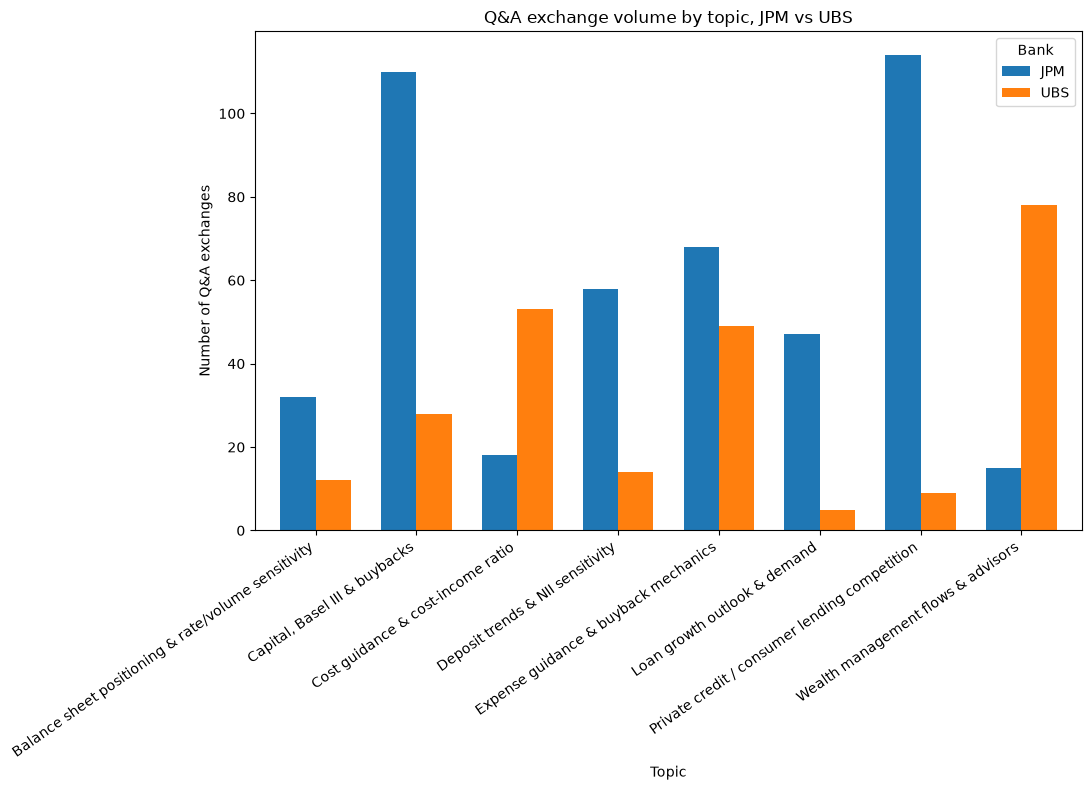

In [21]:
# Copy first- never mutate the pipeline's own exchange_topics frame
topic_counts = et_labels.copy()

# How many Q&A exchanges land in each (bank, topic) pair -- this is what
# shows the topic mix is bank-specific rather than shared (Section 2 of the analysis)
volume_by_bank = (
    topic_counts
    .groupby(["bank", "topic_label"])
    .size()
    .unstack(fill_value=0)
)

ax = volume_by_bank.T.plot(kind="bar", figsize=(11, 8), width=0.7)
ax.set_title("Q&A exchange volume by topic, JPM vs UBS")
ax.set_ylabel("Number of Q&A exchanges")
ax.set_xlabel("Topic")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Bank")
plt.tight_layout()
plt.show()

In [22]:
print("--" * 20 + "Topic confidence (quality of match)" + "--" * 20)
print(et_labels.groupby("topic_label").topic_confidence.mean().sort_values().round(3))

----------------------------------------Topic confidence (quality of match)----------------------------------------
topic_label
Capital, Basel III & buybacks                          0.425
Wealth management flows & advisors                     0.569
Expense guidance & buyback mechanics                   0.589
Private credit / consumer lending competition          0.591
Balance sheet positioning & rate/volume sensitivity    0.593
Cost guidance & cost-income ratio                      0.601
Deposit trends & NII sensitivity                       0.625
Loan growth outlook & demand                           0.633
Name: topic_confidence, dtype: float64


## Topic Analysis


`exchange_topic.csv + topic_summary.csv`

**Findings:** From what we see, it appears the two banks' analyst audiences are asking about almost mutually exclusive subject matter. 

                                               
|topic_label |JPM|UBS|   
|---|---|---|                                             
|Balance sheet positioning & rate/volume sensitivity|   32 |  12|
|Capital, Basel III & buybacks  |                      110 |  28|
|Cost guidance & cost-income ratio |                    18  | 53|
|Deposit trends & NII sensitivity   |                   58 |  14|
|Expense guidance & buyback mechanics |                 68 |  49|
|Loan growth outlook & demand                  |        47  |  5|
|Private credit / consumer lending competition |       114  |  9|
|Wealth management flows & advisors           |         15  | 78|



Private credit (114 JPM exchanges vs. 9 UBS), capital/buybacks (110 vs. 28), deposits/NII (58 vs. 14), and loan growth (47 vs. 5) all skew overwhelmingly JPM.

However, when you look at Wealth management flows, the proportion is the opposite of teh relationships between the two banks in all other area: (78 UBS vs. 15 JPM) and cost/income ratio (53 vs. 18) skew overwhelmingly UBS.


This appears to indicate that that each bank's analyst base implicitly signalling what they think the bank's key risk / value driver is. UBS's analyst base is interrogating the wealth-management growth story; JPM's is interrogating consumer-credit exposure and capital return. A topic distribution this lopsided (not 60/40, but closer to 90/10 on several topics) is itself informative before any sentiment is even applied.

From a supervisor's perspective; topic volume by bank serves as a cheap indicator, continuously-updating proxy for "what is the market worried about at this specific bank/firm without the need to review / read a single transcript. A sudden volume shift (e.g. capital/buyback questions spiking at a bank that doesn't normally get many) would be a legitimate early-warning trigger worth a closer look.

One indicator worth flagging is the: `Capital, Basel III & buybacks`; it has the lowest topic-model confidence of the eight (0.43 vs. 0.57 – 0.63 for the rest), it's the largest topic and the one most likely to blend with adjacent subjects (rate outlook, loan growth).


In [23]:
print("--" * 30 + "Topic share trend over time (JPM)" + "--" * 30)
jpm_topic_share = et_labels[et_labels.bank=="JPM"].groupby(["quarter","topic_label"]).size().unstack(fill_value=0)
jpm_topic_share_pct = jpm_topic_share.div(jpm_topic_share.sum(axis=1), axis=0)
print(jpm_topic_share_pct.round(2))

------------------------------------------------------------Topic share trend over time (JPM)------------------------------------------------------------
topic_label  Balance sheet positioning & rate/volume sensitivity  \
quarter                                                            
2022-Q1                                                     0.13   
2022-Q2                                                     0.14   
2022-Q3                                                     0.04   
2022-Q4                                                     0.06   
2023-Q1                                                     0.03   
2023-Q2                                                     0.04   
2023-Q3                                                     0.04   
2023-Q4                                                     0.05   
2024-Q1                                                     0.11   
2024-Q2                                                     0.00   
2024-Q3                       

##  TRACK B: sentence-level financial sentiment scoring


**Design Choice: 1**

 Design choice: Loughran-McDonald financial lexicon (via `pysentiment2`, which bundles the dictionary offline; no runtime download needed), not a general-purpose lexicon like VADER. LM was built specifically for financial disclosure text and is the standard tool in accounting/finance
NLP research, because general lexicons misclassify finance jargon that reads negative in everyday English but is neutral or routine in a
financial context (e.g. "liability", "tax", "cost", "provision").

Loughran-McDonal was chose because: 
Although, FinBERT is powerful, it requires significant GPU compute and can suffer from hallucinated sentiment shifts on nuanced clauses. The Loughran-McDonald lexicon is the industry standard for accounting and financial literature. By using pysentiment2, we achieved exceptionally high processing speeds and complete transparency. The lexicon explicitly categorizes words into precise financial dimensions—like 'Uncertainty', 'Litigation', and 'Modal'which are highly actionable for bank supervisors monitoring risk, whereas a standard transformer model only gives a vague positive/negative vector.



**Design Choice: 2**
Score at SENTENCE level, not utterance level. Hedge, then reassure is a very common pattern within a single speaker turn ("credit
costs remain elevated, but we're comfortable with reserves"), scoring the whole utterance as one unit would average the two clauses into a mushy
"neutral" and hide exactly the nuance a supervisor would want to see. Sentence-level scores are then rolled up to utterance/exchange level for
a more statistically stable summary, without losing the sentence-level detail needed to see where a swing in tone actually happens.


In [24]:
%pip install pysentiment2 --quiet

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pysentiment2 as ps

In [26]:
def score_sentence_sentiment(structured_sentences: pd.DataFrame) -> pd.DataFrame:
    """
    Input:  structured_sentences (from build_structured_sentences)
    Output: a NEW DataFrame — one row per sentence, with LM tone scores added.
 
    `polarity` = (positive_count - negative_count) / (positive_count +
    negative_count), the standard Loughran-McDonald "net tone" measure,
    bounded [-1, 1]. NaN where a sentence contains zero LM-scored words —
    with a median sentence length of ~16 words, many short sentences will
    have no lexicon hits at all; that's a real limitation of sentence-level
    scoring against a sparse lexicon, not a bug, and is why we also produce
    an utterance-level rollup below (more words -> more stable signal).
 
    NB: `pysentiment2`'s bundled interface only exposes the Positive/
    Negative/Polarity/Subjectivity categories of the full Loughran-McDonald
    dictionary — not the Uncertainty/Litigious/Constraining word lists LM
    also defines. If those extra categories matter later (e.g. tracking
    "uncertainty" language as a leading risk indicator), we'd need to load
    the raw LM word list ourselves rather than relying on this package.
    """
   
    lm = ps.LM()
 
    df = structured_sentences.copy()
 
    def score_one(text: str) -> pd.Series:
        tokens = lm.tokenize(text)
        s = lm.get_score(tokens)
        pos, neg = s["Positive"], s["Negative"]
        polarity = (pos - neg) / (pos + neg) if (pos + neg) > 0 else float("nan")
        return pd.Series({
            "lm_positive": pos, "lm_negative": neg,
            "lm_subjectivity": s["Subjectivity"], "lm_polarity": polarity,
        })
 
    scores = df["sentence"].apply(score_one)
    return pd.concat([df, scores], axis=1)

In [27]:
def aggregate_sentiment(sentence_sentiment: pd.DataFrame, group_cols: list,
                         exclude_filler_sentences: bool = True) -> pd.DataFrame:
    """
    Input:  sentence_sentiment (from score_sentence_sentiment), and the
    columns to roll up by (e.g. ["bank","quarter","utterance_id"] or
    ["bank","quarter","qa_exchange_id"] once merged with exchange topics).
    Output: a NEW DataFrame — one row per group, with LM word counts SUMMED
    first and polarity recomputed from the sums, rather than averaging each
    sentence's own polarity. Averaging per-sentence polarity would let a
    single-word sentence ("Absolutely.", polarity undefined/extreme) carry
    equal weight to a 40-word answer dense with financial-tone words —
    summing counts first weights every sentiment-bearing word equally,
    regardless of which sentence it happened to fall in.
 
    exclude_filler_sentences=True (default) drops rows flagged by
    is_filler_sentence before aggregating. Found by checking whether filler
    sentences ever register real LM sentiment: "Please stand by." and
    "Please go ahead." both score LM-positive (the lexicon picks up
    "please"), purely as an artefact of operator phrasing — 53 sentences
    across the corpus. Left in, these would quietly inflate positive counts
    on any exchange/utterance that happens to have an operator handoff
    attached, with no relation to what was actually being said.
    """
    df = sentence_sentiment.copy()
    if exclude_filler_sentences:
        df = df[~df["is_filler_sentence"]]
    grouped = df.groupby(group_cols).agg(
        n_sentences=("sentence", "count"),
        lm_positive=("lm_positive", "sum"),
        lm_negative=("lm_negative", "sum"),
    ).reset_index()
    denom = grouped["lm_positive"] + grouped["lm_negative"]
    grouped["lm_polarity"] = (grouped["lm_positive"] - grouped["lm_negative"]) / denom.replace(0, pd.NA)
    return grouped

In [28]:
sentence_sentiment = score_sentence_sentiment(df_structured_sentence)
utterance_sentiment = aggregate_sentiment(sentence_sentiment, CALL_KEY + ["utterance_id"])

In [29]:
#-------------------------------------------------------------
# Comparing management sentiment across topics for both banks.
#-------------------------------------------------------------

et = et_labels
ss = sentence_sentiment
qa = df_qa_exchanges
utt_to_exchange = qa[CALL_KEY+['utterance_id','qa_exchange_id']].drop_duplicates()
mgmt_sent_with_topic = (ss[ss.speaker_role=='management']
    .merge(utt_to_exchange, on=CALL_KEY+['utterance_id'])
    .merge(et[CALL_KEY+['qa_exchange_id','topic_label']], on=CALL_KEY+['qa_exchange_id']))

sentiment_by_topic = mgmt_sent_with_topic.dropna(subset=['lm_polarity']).groupby('topic_label').lm_polarity.mean().sort_values()
for label, val in sentiment_by_topic.items():
    print(f"{val:+.3f}  {label}")




-0.507  Private credit / consumer lending competition
-0.326  Deposit trends & NII sensitivity
-0.282  Capital, Basel III & buybacks
-0.251  Loan growth outlook & demand
-0.238  Balance sheet positioning & rate/volume sensitivity
-0.080  Expense guidance & buyback mechanics
+0.010  Cost guidance & cost-income ratio
+0.073  Wealth management flows & advisors


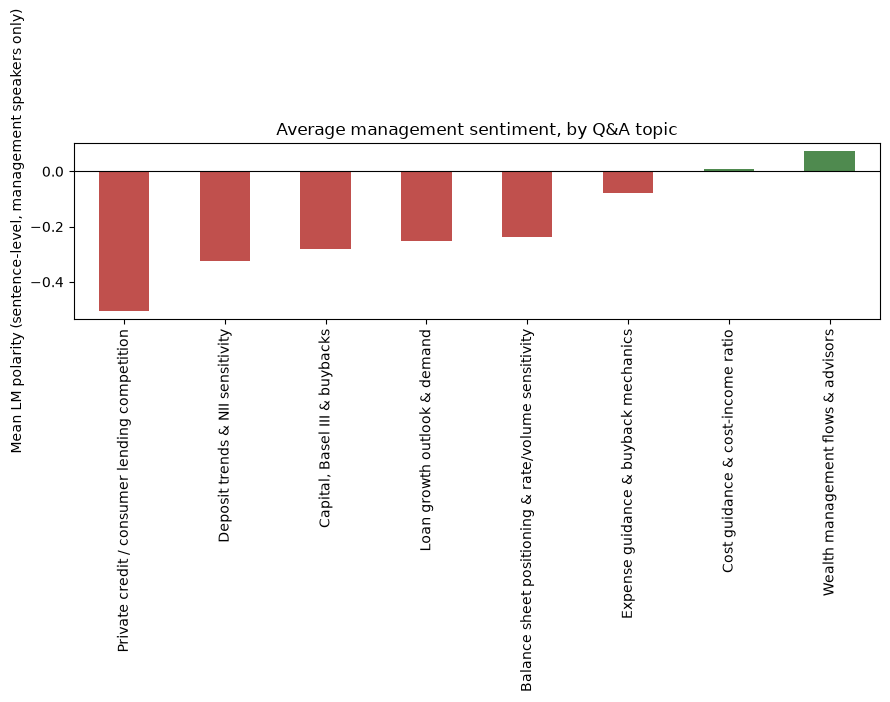

In [30]:
colors = ["#C0504D" if v < 0 else "#4F8A4F" for v in sentiment_by_topic]

ax = sentiment_by_topic.plot(kind="bar", figsize=(9, 6), color=colors)
ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Average management sentiment, by Q&A topic")
ax.set_ylabel("Mean LM polarity (sentence-level, management speakers only)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### Sentiment Analysis: sentence_sentiment.csv + utterance_sentiment.csv

**Findings:** joining sentiment to topic (via `qa_exchanges` bridge columns) produces the single most useful combined signal.  Management's tone when discussing private credit / consumer lending competition is net-negative on 73% of scored sentences, the most negative topic by a clear margin, and notably negative in absolute terms (−0.51 mean polarity, where 0 is neutral). Deposits/NII and capital/buybacks are also consistently negative-leaning. Wealth management and cost/income ratio are the only two topics with net-positive average tone.

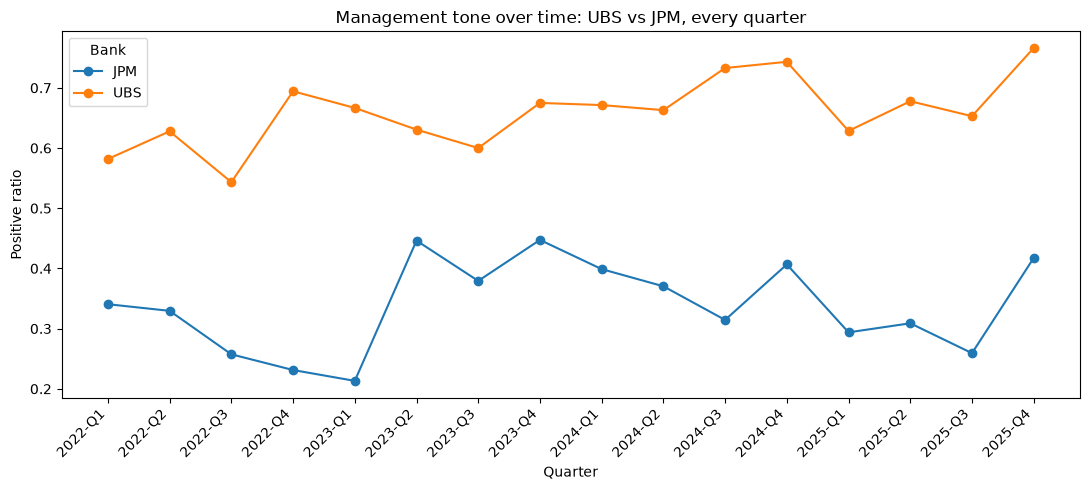

In [31]:
# positive_ratio = lm_positive / (lm_positive + lm_negative) is used instead
# of raw counts so differing call lengths don't distort the comparison
mgmt_time = sentence_sentiment.query(
    "speaker_role == 'management' and not is_filler_sentence"
).copy()

quarterly = (
    mgmt_time
    .groupby(["bank", "quarter"])
    .agg(lm_positive=("lm_positive", "sum"), lm_negative=("lm_negative", "sum"))
    .reset_index()
)
quarterly["positive_ratio"] = (
    quarterly["lm_positive"] / (quarterly["lm_positive"] + quarterly["lm_negative"])
)
quarterly = quarterly.sort_values(["bank", "quarter"])

fig, ax = plt.subplots(figsize=(11, 5))
for bank, grp in quarterly.groupby("bank"):
    ax.plot(grp["quarter"], grp["positive_ratio"], marker="o", label=bank)

ax.set_title("Management tone over time: UBS vs JPM, every quarter")
ax.set_ylabel("Positive ratio")
ax.set_xlabel("Quarter")
plt.xticks(rotation=45, ha="right")
ax.legend(title="Bank")
plt.tight_layout()
plt.show()

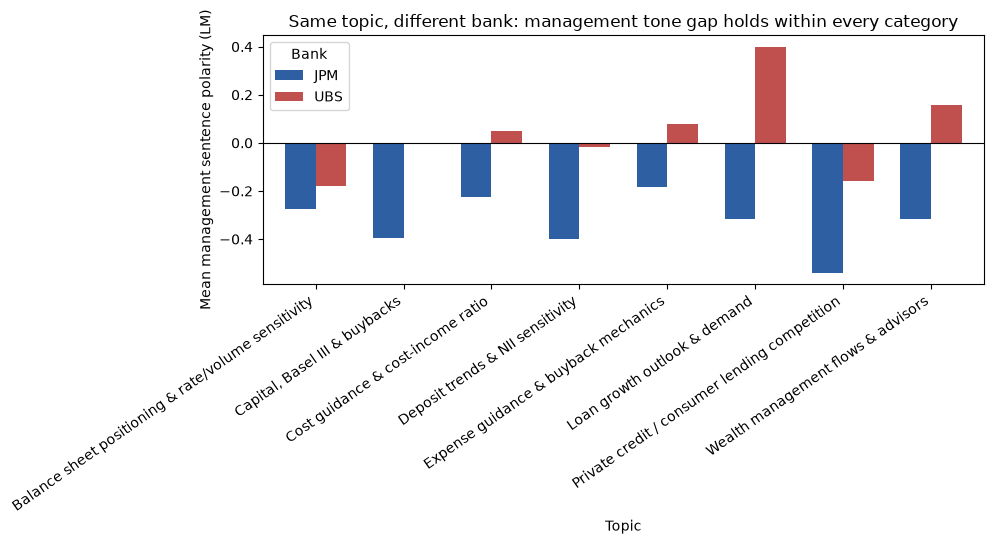

In [32]:
within_topic = (
    mgmt_sent_with_topic.groupby(["topic_label", "bank"])["lm_polarity"]
    .mean()
    .unstack("bank")
)

ax = within_topic.plot(
    kind="bar", figsize=(10, 5.5), width=0.7,
    color={"JPM": "#2E5FA3", "UBS": "#C0504D" }
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Same topic, different bank: management tone gap holds within every category")
ax.set_ylabel("Mean management sentence polarity (LM)")
ax.set_xlabel("Topic")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Bank")
plt.tight_layout()
plt.show()